### Importing Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from keras.models import Sequential
import numpy as np
import os

### CONFIGURATION

In [3]:

OUTPUT_PATH = '/content/drive/MyDrive/SignBridge/Model_Saved_LSTM'

ACTIONS = np.array(["Bathroom", "Bill", "Bring", "Broken", "Clean",
                    "Cold","Dirty", "Find", "Food", "Help", "Hot", "I","Key", "Luggage",
                    "Need", "No", "Nothing", "Now","Please", "Room", "Towel", "Water"])
PREPROCESSING_PATH = "/content/drive/MyDrive/SignBridge/Preprocessed"

os.makedirs(OUTPUT_PATH, exist_ok=True)

### Load

In [4]:
X_train = np.load(os.path.join(PREPROCESSING_PATH, 'X_train.npy'))
X_train = X_train.astype(np.float32)
y_train = np.load(os.path.join(PREPROCESSING_PATH, 'y_train.npy'))

X_test  = np.load(os.path.join(PREPROCESSING_PATH, 'X_test.npy')).astype(np.float32)
y_test  = np.load(os.path.join(PREPROCESSING_PATH, 'y_test.npy'))

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}  ← unseen, no augmentation")

num_classes = y_train.shape[1]

X_train : (23470, 122, 288)
y_train : (23470, 22)
X_test  : (1183, 122, 288)
y_test  : (1183, 22)

Training samples : 23470
Testing samples  : 1183  ← unseen, no augmentation


### MODEL — LSTM (no Bidirectional)

In [5]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True, activation='tanh'),
    Dropout(0.3),
    LSTM(128, return_sequences=True, activation='tanh'),
    Dropout(0.3),
    LSTM(64, return_sequences=False, activation='tanh'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 122, 64)        │        90,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 122, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 122, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 122, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,438 (954.84 KB)

 Trainable params: 244,310 (954.34 KB)

 Non-trainable params: 128 (512.00 B)

### CALLBACKS

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(OUTPUT_PATH, 'best_model.weights.h5'),
    monitor='val_categorical_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

### TRAINING

In [7]:
print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Starting training...
Epoch 1/100
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - categorical_accuracy: 0.2224 - loss: 2.3486
Epoch 1: val_categorical_accuracy improved from None to 0.37109, saving model to /content/drive/MyDrive/SignBridge/Model_Saved_LSTM/best_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/SignBridge/Model_Saved_LSTM/best_model.weights.h5
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - categorical_accuracy: 0.2728 - loss: 2.0730 - val_categorical_accuracy: 0.3711 - val_loss: 1.5786 - learning_rate: 0.0010
Epoch 2/100
1466/1467 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - categorical_accuracy: 0.4241 - loss: 1.4679
Epoch 2: val_categorical_accuracy improved from 0.37109 to 0.58242, saving model to /content/drive/MyDrive/SignBridge/Model_Saved_LSTM/best_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/SignBridge/Model_Saved_LSTM/best_model.weights.h5
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - categorical_accuracy: 0.4725 - 

### EVALUATION


TRUE Test Loss     : 0.1968
TRUE Test Accuracy : 96.96%

Classification Report:
              precision    recall  f1-score   support

    Bathroom       1.00      1.00      1.00        60
        Bill       1.00      0.91      0.95        64
       Bring       1.00      0.98      0.99        59
      Broken       0.96      1.00      0.98        53
       Clean       0.98      0.98      0.98        60
        Cold       0.98      0.96      0.97        52
       Dirty       1.00      1.00      1.00        56
        Find       1.00      1.00      1.00        43
        Food       0.93      0.98      0.96        56
        Help       0.83      0.93      0.88        46
         Hot       0.98      1.00      0.99        58
           I       1.00      0.95      0.97        58
         Key       0.94      0.97      0.95        60
     Luggage       1.00      0.98      0.99        57
        Need       0.97      0.97      0.97        68
          No       1.00      1.00      1.00        45


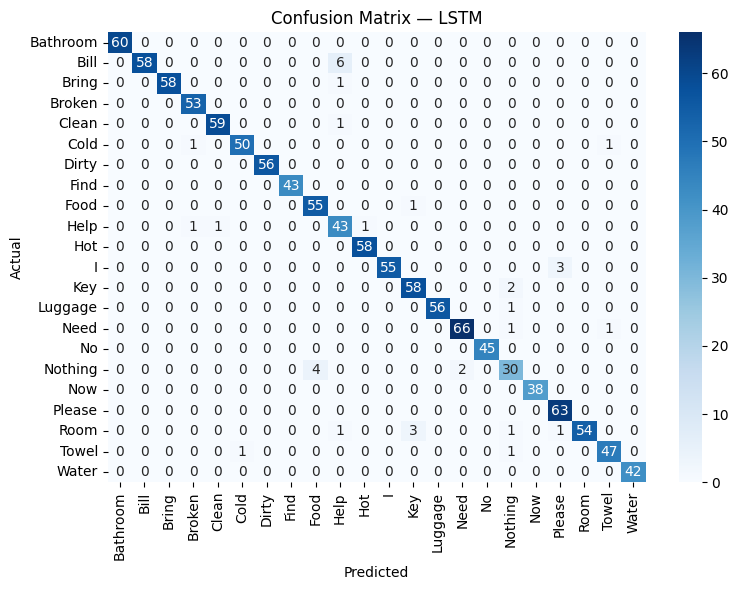

Confusion matrix saved


In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"TRUE Test Loss     : {loss:.4f}")
print(f"TRUE Test Accuracy : {accuracy * 100:.2f}%")
print(f"{'='*50}")

y_pred     = model.predict(X_test, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_cls, y_pred_cls, target_names=ACTIONS))

print("Average Confidence Per Class (correct predictions only):")
for i, action in enumerate(ACTIONS):
    class_mask   = y_true_cls == i
    correct_mask = (y_pred_cls == y_true_cls) & class_mask
    if correct_mask.sum() > 0:
        avg_conf = y_pred[correct_mask, i].mean() * 100
        print(f"  {action:<12} {avg_conf:.1f}%")

cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIONS, yticklabels=ACTIONS)
plt.title('Confusion Matrix — LSTM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'confusion_matrix.png'))
plt.show()
print("Confusion matrix saved")

### Save Model

In [9]:
model.save(os.path.join(OUTPUT_PATH, 'signbridge_lstm_model.h5'))
print("\nSaved: signbridge_lstm_model.h5")

model.save_weights(os.path.join(OUTPUT_PATH, 'signbridge_lstm_weights.weights.h5'))
print("Saved: signbridge_lstm_weights.weights.h5")

weights = model.get_weights()
np.save(os.path.join(OUTPUT_PATH, 'model_weights.npy'),
        np.array(weights, dtype=object))
print("Saved: model_weights.npy")

print("\nPer-Class Accuracy:")
for i, action in enumerate(ACTIONS):
    class_mask = y_true_cls == i
    if class_mask.sum() > 0:
        acc = (y_pred_cls[class_mask] == i).sum() / class_mask.sum() * 100
        print(f"  {action:<12} {acc:.1f}%")

print("\nTop Confusions:")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    if cm_copy[idx] == 0:
        break
    print(f"  {ACTIONS[idx[0]]:<12} → {ACTIONS[idx[1]]:<12} {cm_copy[idx]} times")
    cm_copy[idx] = 0


Saved: signbridge_lstm_model.h5
Saved: signbridge_lstm_weights.weights.h5
Saved: model_weights.npy

Per-Class Accuracy:
  Bathroom     100.0%
  Bill         90.6%
  Bring        98.3%
  Broken       100.0%
  Clean        98.3%
  Cold         96.2%
  Dirty        100.0%
  Find         100.0%
  Food         98.2%
  Help         93.5%
  Hot          100.0%
  I            94.8%
  Key          96.7%
  Luggage      98.2%
  Need         97.1%
  No           100.0%
  Nothing      83.3%
  Now          100.0%
  Please       100.0%
  Room         90.0%
  Towel        95.9%
  Water        100.0%

Top Confusions:
  Bill         → Help         6 times
  Nothing      → Food         4 times
  I            → Please       3 times
  Room         → Key          3 times
  Key          → Nothing      2 times


In [10]:

np.save(os.path.join(OUTPUT_PATH, 'y_pred.npy'), y_pred_cls)
np.save(os.path.join(OUTPUT_PATH, 'y_true.npy'), y_true_cls)
np.save(os.path.join(OUTPUT_PATH, 'y_pred_prob.npy'), y_pred)
print("Saved: predictions for comparison")

Saved: predictions for comparison
